# HPCG SpMV filtering smoke test (0622 dsub)

Triad-only analysis derived from the 0617 filtering notebook. The input is discovered from the data pulled back to af309.


In [23]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
DATE_BASE = "20260623"
SHUFFLE_SELECT = "shuffle0"
RUN_ID = os.environ.get("RUN_ID") or os.environ.get("TRIAD_RUN_ID")
DATA_BASE = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}")


def discover_run_roots():
    roots = []
    for host_dir in sorted(DATA_BASE.iterdir()) if DATA_BASE.exists() else []:
        output_root = host_dir / "output_hpcg_spmv_filt_dsub"
        if not output_root.exists():
            continue
        stamps = [output_root / RUN_ID] if RUN_ID else sorted(
            (p for p in output_root.iterdir() if p.is_dir()), reverse=True
        )
        for stamp in stamps:
            shuffle = stamp / SHUFFLE_SELECT
            if shuffle.exists():
                roots.append(shuffle)
                break
    if not roots:
        requested = RUN_ID or "latest available run"
        raise FileNotFoundError(f"No Triad data for {requested} under {DATA_BASE}")
    return roots


DATA_FOLDERS = discover_run_roots()
HOST_ORDER = [p.parts[p.parts.index('data') + 2] for p in DATA_FOLDERS]
RUN_ROOTS = [p.parent for p in DATA_FOLDERS]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 1.0
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0623_full_hpcg_spmv_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e', 'clock_gettime': '#ff7f0e', 'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c', 'papi': '#d62728', 'papix6': '#9467bd',
    'likwid': '#8c564b', 'tsc': '#1f77b4', 'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf', 'cntvct': '#e377c2', 'cntvcto': '#e377c2',
}
TIMER_LABELS = {
    'tsc': 'TSC', 'tsc_fence': 'TSC_Fence', 'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime', 'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime', 'mpi_wtime': 'MPI_Wtime', 'papi': 'PAPI',
    'papix6': 'PAPIx6', 'likwid': 'LIKWID', 'cntvct': 'CNTVCT', 'cntvcto': 'CNTVCT',
}
KERNEL_LABELS = {'hpcg_spmv': 'HPCG SpMV'}
HOST_LABELS = {
    'cgnr6760pn2': 'Intel Xeon 6760P', 'camd9554n1': 'AMD EPYC 9554',
    'camd9554n2': 'AMD EPYC 9554', 'c920bn3': 'Kunpeng 920B',
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260623/c920bn3/output_hpcg_spmv_filt_dsub/20260623-full-v2-hpcg-spmv-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260623/camd9554n1/output_hpcg_spmv_filt_dsub/20260623-full-v2-hpcg-spmv-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260623/cgnr6760pn2/output_hpcg_spmv_filt_dsub/20260623-full-v2-hpcg-spmv-dsub/shuffle2
host_order: ['c920bn3', 'camd9554n1', 'cgnr6760pn2']
shuffle_label: c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2


In [25]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
entries = entries[entries['kernel'] == 'hpcg_spmv'].copy()
if entries.empty:
    raise RuntimeError('No hpcg_spmv filtered entries found')
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
entries['timer'] = entries['timer'].replace('cntvcto', 'cntvct')
# entries = entries[(entries['timer'] != 'papi') & (entries['timer'] != 'cgt')]


entries: 126


# ER/EP/Wasserstein

In [26]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[~df['kernel'].str.contains('tsc')]

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
6,c920bn3,hpcg_spmv,cgt,64,8,0.0,0.029309,25.251256,199.733878,180.704330
13,c920bn3,hpcg_spmv,cntvct,64,8,0.0,0.018385,15.736683,213.617566,199.726550
20,c920bn3,hpcg_spmv,papi,64,8,0.0,0.004392,4.422111,226.139125,220.537021
27,c920bn3,hpcg_spmv,papix6,64,8,0.0,0.011505,11.675377,223.181061,208.608379
34,c920bn3,hpcg_spmv,wtime,64,8,0.0,0.016622,14.336683,203.134142,199.474480
0,c920bn3,hpcg_spmv,cgt,64,12,0.0,0.009198,18.887437,533.024831,520.854561
7,c920bn3,hpcg_spmv,cntvct,64,12,0.0,0.004636,9.487437,543.654307,534.696130
14,c920bn3,hpcg_spmv,papi,64,12,0.0,0.026969,62.499497,652.392327,586.833514
21,c920bn3,hpcg_spmv,papix6,64,12,0.0,0.053765,126.170854,675.155195,543.908260
28,c920bn3,hpcg_spmv,wtime,64,12,0.0,0.007319,15.051256,540.683867,532.721867


In [27]:
print('kernels:', sorted(df['kernel'].unique()))
print(df[['host', 'kernel', 'timer', 'np', 'size', 'nsampRatio', 'ep', 'er', 'wd']])


kernels: ['hpcg_spmv']
            host     kernel   timer  np  size  nsampRatio   ep        er  \
6        c920bn3  hpcg_spmv     cgt  64     8         0.5  0.0  0.029309   
13       c920bn3  hpcg_spmv  cntvct  64     8         0.5  0.0  0.018385   
20       c920bn3  hpcg_spmv    papi  64     8         0.5  0.0  0.004392   
27       c920bn3  hpcg_spmv  papix6  64     8         0.5  0.0  0.011505   
34       c920bn3  hpcg_spmv   wtime  64     8         0.5  0.0  0.016622   
..           ...        ...     ...  ..   ...         ...  ...       ...   
75   cgnr6760pn2  hpcg_spmv     cgt  64    64         0.5  0.0  0.002769   
82   cgnr6760pn2  hpcg_spmv    papi  64    64         0.5  0.0  0.004746   
89   cgnr6760pn2  hpcg_spmv  papix6  64    64         0.5  0.0  0.003320   
96   cgnr6760pn2  hpcg_spmv     tsc  64    64         0.5  0.0  0.001413   
103  cgnr6760pn2  hpcg_spmv   wtime  64    64         0.5  0.0  0.001229   

              wd  
6      25.251256  
13     15.736683  
20     

In [28]:
# df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
# df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

# df['shuffle'] = df['shuffle'].astype('string')
# df
# for k,v_df in df.groupby(['np','size','host','nsampRatio','nsamp','kernel','host','shuffle']):
#     print(k)
#     print(v_df.columns)

In [29]:
# Cross-timer divergence before (T_m) / after (T_r).
# A single-timer smoke run has no meaningful cross-timer comparison and is skipped explicitly.
from scipy.stats import wasserstein_distance

EP_THRESHOLD = 0.1
ER_THRESHOLD = 0.1
REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvct'}


def divergence_table(src, group_keys):
    rows = []
    for gv, group in src.groupby(group_keys):
        keys = gv if isinstance(gv, tuple) else (gv,)
        row = dict(zip(group_keys, keys))
        timers = list(group['timer'].dropna().unique())
        if len(timers) < 2:
            continue
        ref_timer = REF_TIMER_BY_HOST.get(row['host'])
        if ref_timer not in timers:
            ref_timer = sorted(timers, key=timer_sort_key)[0]
        ref = group[group['timer'] == ref_timer].iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float)
        base = float(np.mean(ref_tm)) if ref_tm.size else np.nan
        tm_dist, tr_dist = [], []
        for _, item in group[group['timer'] != ref_timer].iterrows():
            tm_dist.append(wasserstein_distance(item['tm_seq'], ref['tm_seq']))
            tr_dist.append(wasserstein_distance(item['tr_seq'], ref['tr_seq']))
        sum_tm, sum_tr = float(np.sum(tm_dist)), float(np.sum(tr_dist))
        row.update(
            d_before=np.mean(tm_dist) / base if base > 0 else np.nan,
            d_after=np.mean(tr_dist) / base if base > 0 else np.nan,
            reduction=(sum_tm - sum_tr) / sum_tm if sum_tm > 0 else np.nan,
        )
        rows.append(row)
    return pd.DataFrame(rows)


div_df = divergence_table(df, ['kernel', 'host', 'size', 'nsampRatio'])
if div_df.empty:
    print('SKIP cross-timer divergence: fewer than two timers are available for each smoke-test group.')
else:
    print(div_df)


       kernel         host  size  nsampRatio  d_before   d_after  reduction
0   hpcg_spmv      c920bn3     8         0.5  0.096573  0.016094   0.833352
1   hpcg_spmv      c920bn3    12         0.5  0.073657  0.012639   0.828404
2   hpcg_spmv      c920bn3    16         0.5  0.090284  0.033667   0.627102
3   hpcg_spmv      c920bn3    24         0.5  0.066185  0.062743   0.052003
4   hpcg_spmv      c920bn3    32         0.5  0.034308  0.031040   0.095247
5   hpcg_spmv      c920bn3    48         0.5  0.009262  0.031772  -2.430301
6   hpcg_spmv      c920bn3    64         0.5  0.008908  0.035775  -3.015948
7   hpcg_spmv   camd9554n1     8         0.5  0.377851  0.095091   0.748337
8   hpcg_spmv   camd9554n1    12         0.5  0.106815  0.092395   0.135002
9   hpcg_spmv   camd9554n1    16         0.5  0.080578  0.113187  -0.404688
10  hpcg_spmv   camd9554n1    24         0.5  0.093862  0.050011   0.467184
11  hpcg_spmv   camd9554n1    32         0.5  0.016016  0.013412   0.162599
12  hpcg_spm

In [30]:
if div_df.empty:
    print('SKIP divergence ranking: no cross-timer result.')
else:
    display(div_df.sort_values('reduction', ascending=False))


,kernel,host,size,nsampRatio,d_before,d_after,reduction
0,hpcg_spmv,c920bn3,8,0.5,0.096573,0.016094,0.833352
1,hpcg_spmv,c920bn3,12,0.5,0.073657,0.012639,0.828404
7,hpcg_spmv,camd9554n1,8,0.5,0.377851,0.095091,0.748337
2,hpcg_spmv,c920bn3,16,0.5,0.090284,0.033667,0.627102
10,hpcg_spmv,camd9554n1,24,0.5,0.093862,0.050011,0.467184
14,hpcg_spmv,cgnr6760pn2,8,0.5,0.115427,0.078791,0.317390
11,hpcg_spmv,camd9554n1,32,0.5,0.016016,0.013412,0.162599
8,hpcg_spmv,camd9554n1,12,0.5,0.106815,0.092395,0.135002
15,hpcg_spmv,cgnr6760pn2,12,0.5,0.112198,0.101481,0.095520
4,hpcg_spmv,c920bn3,32,0.5,0.034308,0.031040,0.095247


In [31]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.1 and er <= 0.1):
  HPCG SpMV (hpcg_spmv): [8, 12, 16, 32, 48]


# Filt Plot

In [32]:
entries['nsamp'].unique()

array([  3117,   5771,  23462,  93995, 260931, 479928,   1334,   5756,
        23011,  91944, 259550, 481762,   3364,   6192,  24752,  93952,
       262774, 491319,   1537,   3379,   6293,  24810,  95359, 262861,
       490775,   1538,   3118,   5785,  23418,  94279, 260614, 480733,
         3662,   6799,  16299, 106596, 318315, 597762,   1553,   4578,
         7729,  17696, 106333, 317136, 595883,   2484,   3848,   6085,
        15941, 106238, 316810, 595434,   2312,   3647,   6767,  16096,
       105403, 316909, 596843,   1551,   3664,   6829,  16315, 106348,
       317833, 598009,   1567,   3582,   6696,  29250,  53832, 159919,
       311960,   1505,   3749,   6896,  27358,  53996, 166909, 308393,
         1708,   3056,   5420,  28446,  53664, 163051, 313604,   1370,
         3509,   6636,  26900,  52834, 161785, 311487,   1434,   3632,
         6710,  28922,  53626, 160623, 313088,   1491])

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=8  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=921.07 ns  tr_median=879.44 ns
host=c920bn3 timer=cgt  tm_median=925.75 ns  tr_median=873.70 ns
host=c920bn3 timer=wtime  tm_median=926.86 ns  tr_median=876.61 ns
host=c920bn3 timer=papi  tm_median=1063.18 ns  tr_median=878.97 ns
host=c920bn3 timer=papix6  tm_median=1069.60 ns  tr_median=876.17 ns
host=camd9554n1 timer=tsc  tm_median=1002.55 ns  tr_median=982.56 ns
host=camd9554n1 timer=cgt  tm_median=965.70 ns  tr_median=824.62 ns
host=camd9554n1 timer=wtime  tm_median=1011.86 ns  tr_median=919.91 ns
host=camd9554n1 timer=papi  tm_median=1607.26 ns  tr_median=977.26 ns
host=camd9554n1 timer=papix6  tm_median=1493.03 ns  tr_median=732.03 ns
host=cgnr6760pn2 timer=tsc  tm_median=1304.38 ns  tr_median=1264.22 ns
host=cgnr6760pn2 timer=cgt  tm_median=1368.02 ns  tr_medi

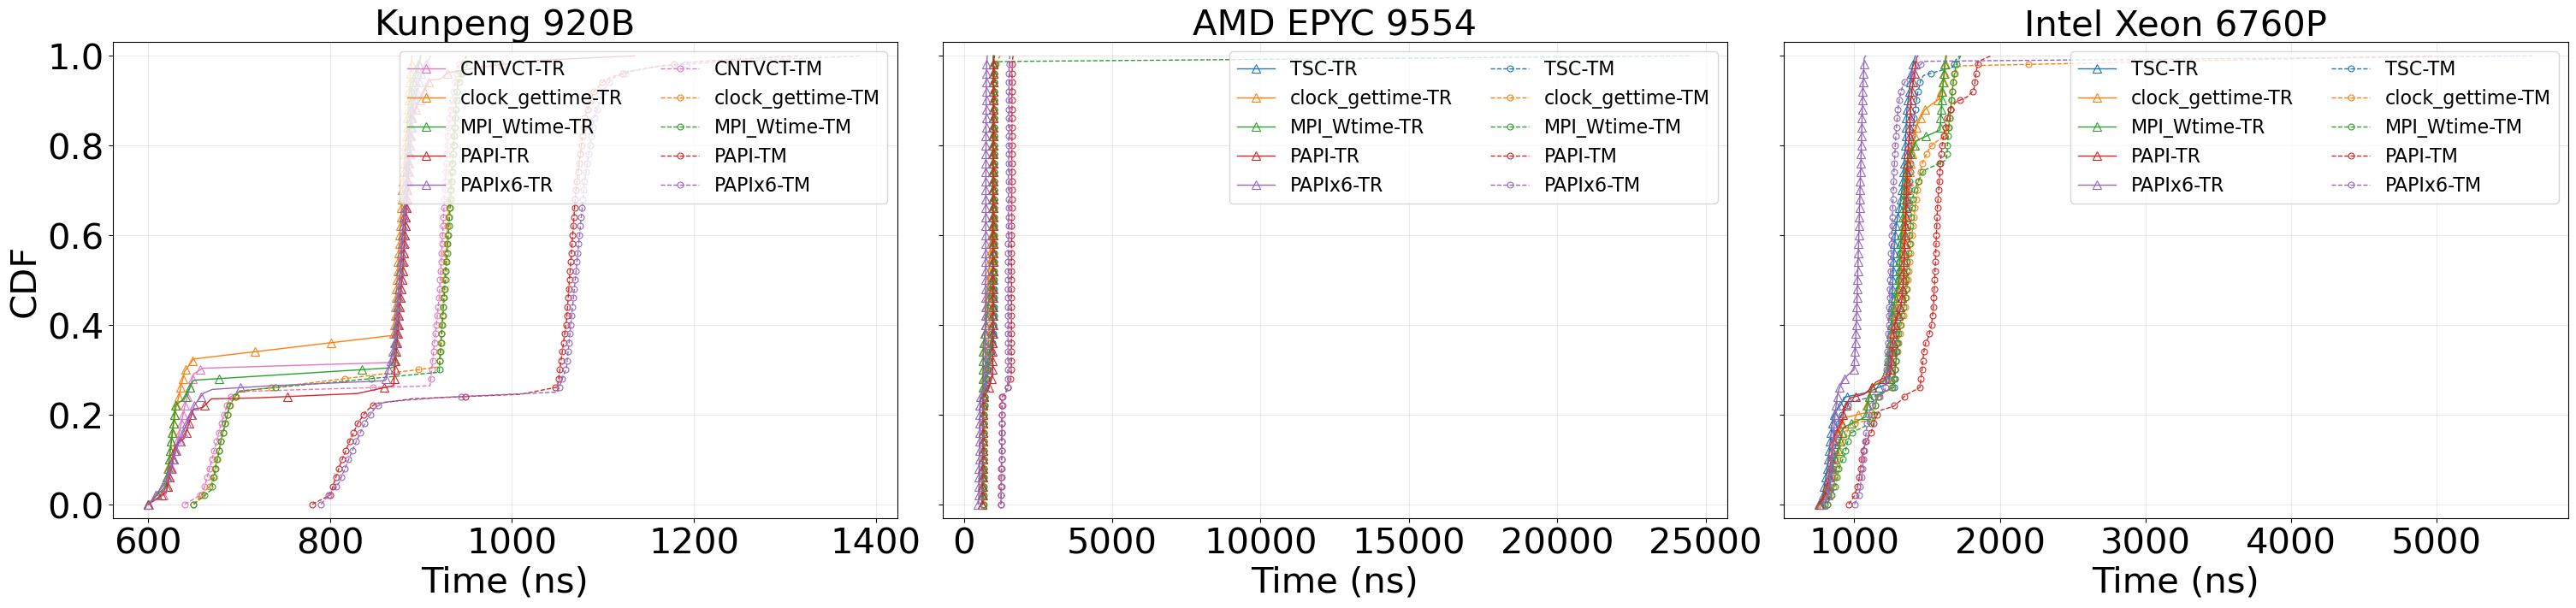

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=12  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=2150.30 ns  tr_median=2087.80 ns
host=c920bn3 timer=cgt  tm_median=2156.73 ns  tr_median=2086.10 ns
host=c920bn3 timer=wtime  tm_median=2159.12 ns  tr_median=2088.68 ns
host=c920bn3 timer=papi  tm_median=2327.27 ns  tr_median=2111.30 ns
host=c920bn3 timer=papix6  tm_median=2339.01 ns  tr_median=2102.27 ns
host=camd9554n1 timer=tsc  tm_median=2356.32 ns  tr_median=2325.54 ns
host=camd9554n1 timer=cgt  tm_median=2365.18 ns  tr_median=2323.71 ns
host=camd9554n1 timer=wtime  tm_median=2369.40 ns  tr_median=2327.92 ns
host=camd9554n1 timer=papi  tm_median=2958.03 ns  tr_median=1981.83 ns
host=camd9554n1 timer=papix6  tm_median=2482.89 ns  tr_median=1706.77 ns
host=cgnr6760pn2 timer=tsc  tm_median=3189.44 ns  tr_median=3138.59 ns
host=cgnr6760pn2 timer=cgt  tm_median=3255

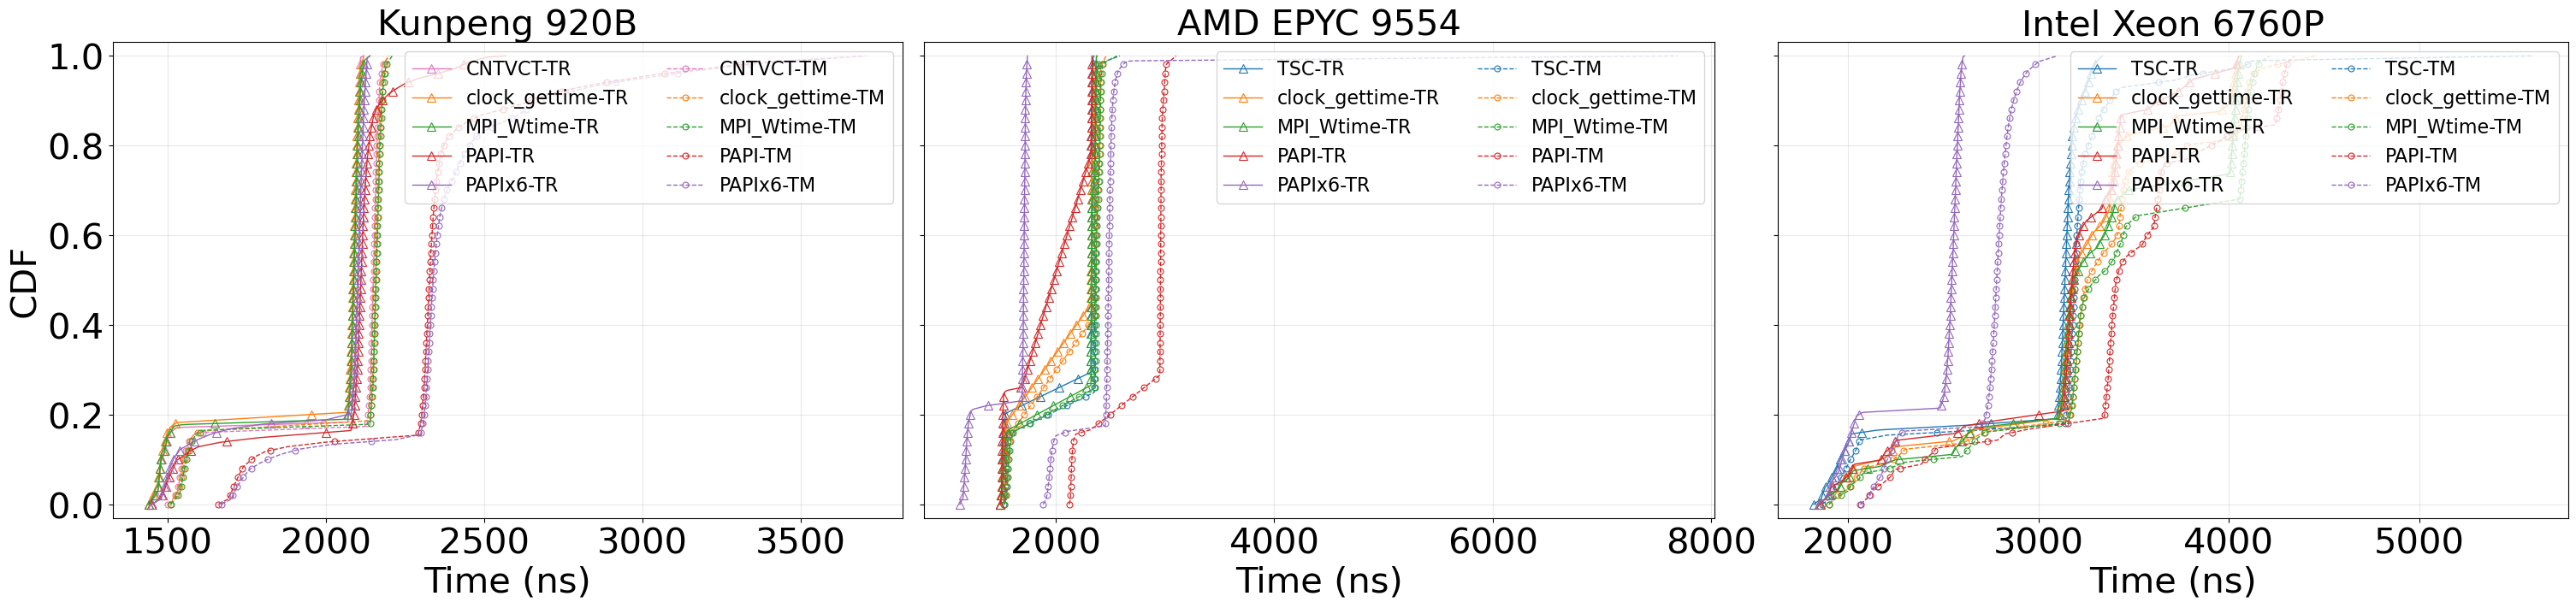

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=16  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=3975.13 ns  tr_median=3864.55 ns
host=c920bn3 timer=cgt  tm_median=3978.93 ns  tr_median=3857.98 ns
host=c920bn3 timer=wtime  tm_median=3990.50 ns  tr_median=3866.61 ns
host=c920bn3 timer=papi  tm_median=4277.78 ns  tr_median=3983.21 ns
host=c920bn3 timer=papix6  tm_median=4343.85 ns  tr_median=3978.88 ns
host=camd9554n1 timer=tsc  tm_median=4378.07 ns  tr_median=4345.97 ns
host=camd9554n1 timer=cgt  tm_median=4132.68 ns  tr_median=4083.92 ns
host=camd9554n1 timer=wtime  tm_median=4406.90 ns  tr_median=4359.28 ns
host=camd9554n1 timer=papi  tm_median=4985.68 ns  tr_median=4236.24 ns
host=camd9554n1 timer=papix6  tm_median=3927.54 ns  tr_median=3102.35 ns
host=cgnr6760pn2 timer=tsc  tm_median=6033.60 ns  tr_median=5963.00 ns
host=cgnr6760pn2 timer=cgt  tm_median=6086

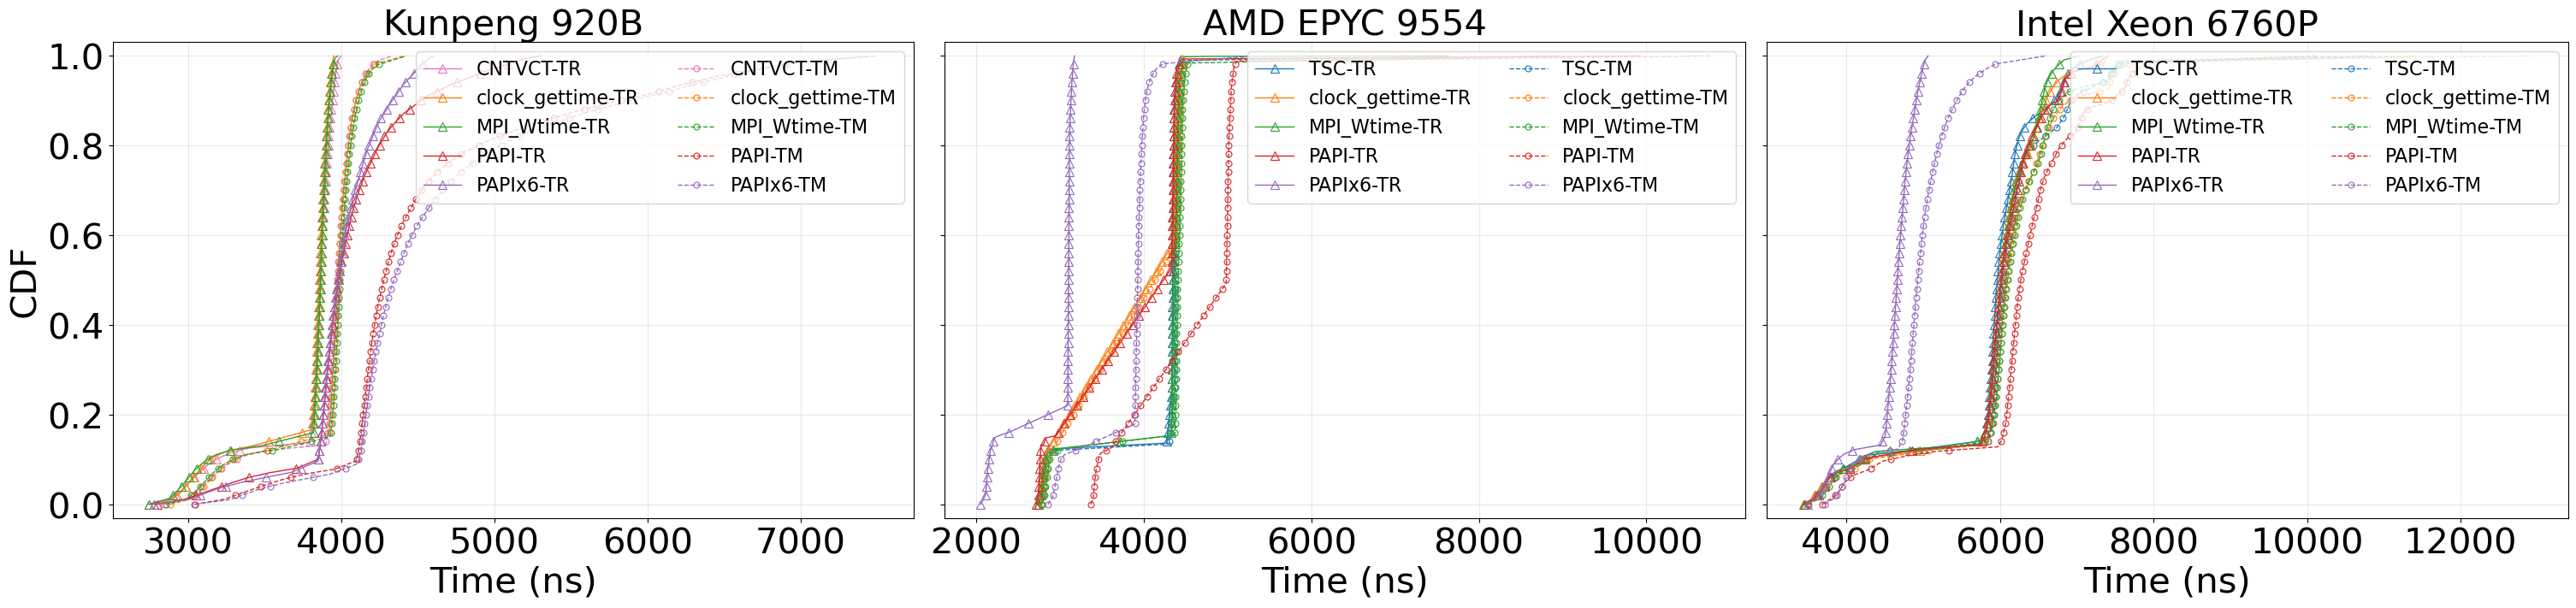

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=24  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=15875.02 ns  tr_median=13652.82 ns
host=c920bn3 timer=cgt  tm_median=16176.01 ns  tr_median=13928.51 ns
host=c920bn3 timer=wtime  tm_median=16151.08 ns  tr_median=14072.85 ns
host=c920bn3 timer=papi  tm_median=17062.35 ns  tr_median=14865.80 ns
host=c920bn3 timer=papix6  tm_median=17106.39 ns  tr_median=15382.61 ns
host=camd9554n1 timer=tsc  tm_median=10383.04 ns  tr_median=10328.23 ns
host=camd9554n1 timer=cgt  tm_median=10515.55 ns  tr_median=10452.80 ns
host=camd9554n1 timer=wtime  tm_median=10519.81 ns  tr_median=10459.43 ns
host=camd9554n1 timer=papi  tm_median=11417.01 ns  tr_median=10616.63 ns
host=camd9554n1 timer=papix6  tm_median=10269.17 ns  tr_median=9111.03 ns
host=cgnr6760pn2 timer=tsc  tm_median=24447.77 ns  tr_median=24280.92 ns
host=cgnr6760pn2 time

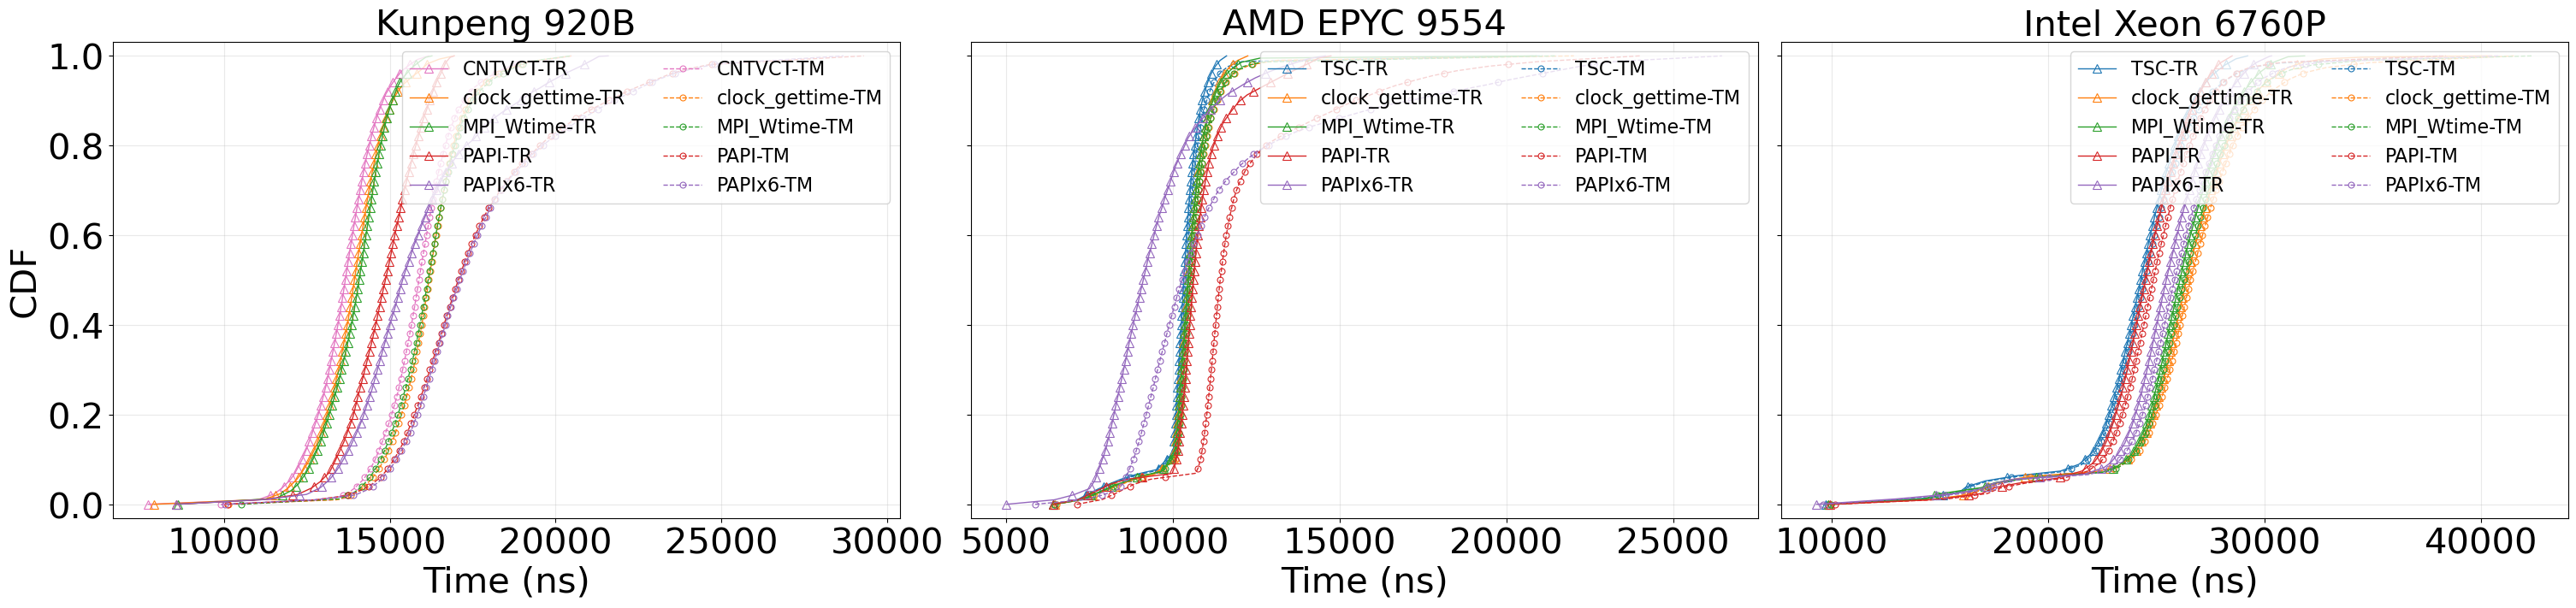

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=32  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=63328.67 ns  tr_median=62018.71 ns
host=c920bn3 timer=cgt  tm_median=64745.57 ns  tr_median=62910.08 ns
host=c920bn3 timer=wtime  tm_median=64970.93 ns  tr_median=59840.12 ns
host=c920bn3 timer=papi  tm_median=64717.86 ns  tr_median=60369.46 ns
host=c920bn3 timer=papix6  tm_median=65723.51 ns  tr_median=63022.56 ns
host=camd9554n1 timer=tsc  tm_median=67962.29 ns  tr_median=67606.89 ns
host=camd9554n1 timer=cgt  tm_median=68757.52 ns  tr_median=68378.15 ns
host=camd9554n1 timer=wtime  tm_median=68593.53 ns  tr_median=68210.45 ns
host=camd9554n1 timer=papi  tm_median=68570.71 ns  tr_median=67371.40 ns
host=camd9554n1 timer=papix6  tm_median=68518.53 ns  tr_median=67205.36 ns
host=cgnr6760pn2 timer=tsc  tm_median=48001.42 ns  tr_median=47599.38 ns
host=cgnr6760pn2 tim

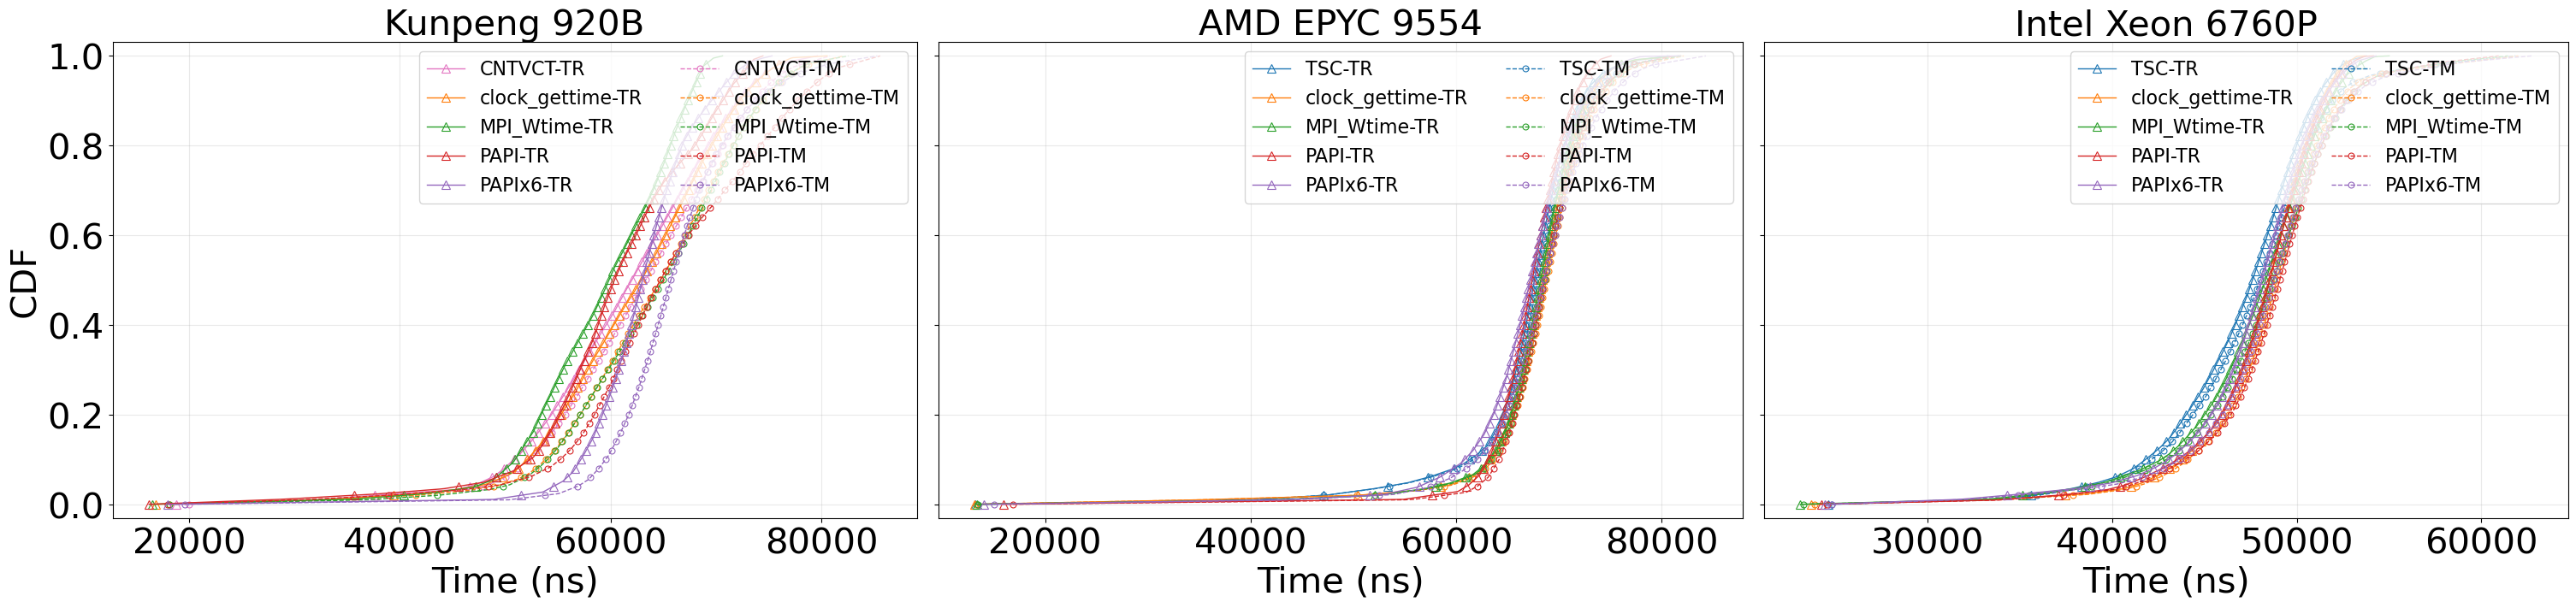

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=48  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=178983.92 ns  tr_median=175007.79 ns
host=c920bn3 timer=cgt  tm_median=179910.04 ns  tr_median=174257.18 ns
host=c920bn3 timer=wtime  tm_median=179692.84 ns  tr_median=164044.28 ns
host=c920bn3 timer=papi  tm_median=181195.80 ns  tr_median=168075.74 ns
host=c920bn3 timer=papix6  tm_median=181243.96 ns  tr_median=173985.62 ns
host=camd9554n1 timer=tsc  tm_median=204444.66 ns  tr_median=203137.23 ns
host=camd9554n1 timer=cgt  tm_median=205323.87 ns  tr_median=203983.94 ns
host=camd9554n1 timer=wtime  tm_median=205010.10 ns  tr_median=203695.16 ns
host=camd9554n1 timer=papi  tm_median=204610.20 ns  tr_median=202442.22 ns
host=camd9554n1 timer=papix6  tm_median=204391.68 ns  tr_median=202005.20 ns
host=cgnr6760pn2 timer=tsc  tm_median=146655.65 ns  tr_median=145236.94 n

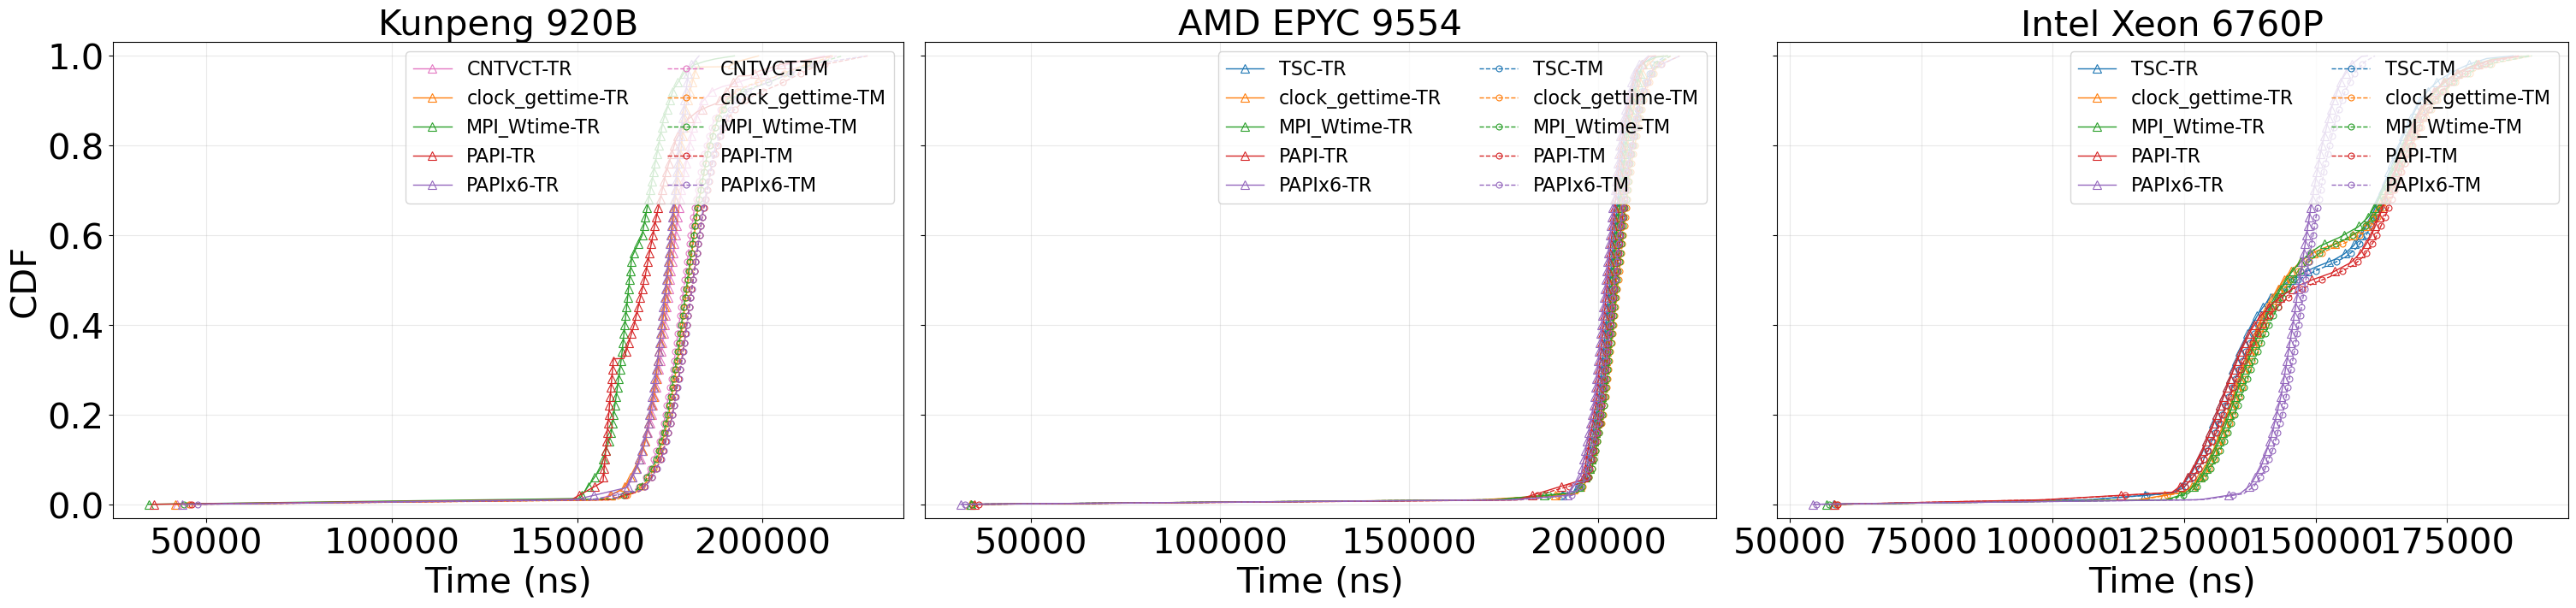

[FILT CDF]  kernel=HPCG SpMV  c920bn3-shuffle2_camd9554n1-shuffle2_cgnr6760pn2-shuffle2  np=64  size=64  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=331959.32 ns  tr_median=319768.87 ns
host=c920bn3 timer=cgt  tm_median=330636.63 ns  tr_median=316654.75 ns
host=c920bn3 timer=wtime  tm_median=331250.80 ns  tr_median=314220.34 ns
host=c920bn3 timer=papi  tm_median=338599.28 ns  tr_median=280770.55 ns
host=c920bn3 timer=papix6  tm_median=338282.11 ns  tr_median=323410.18 ns
host=camd9554n1 timer=tsc  tm_median=385055.69 ns  tr_median=382203.50 ns
host=camd9554n1 timer=cgt  tm_median=385603.47 ns  tr_median=382761.92 ns
host=camd9554n1 timer=wtime  tm_median=385748.88 ns  tr_median=382894.37 ns
host=camd9554n1 timer=papi  tm_median=384457.36 ns  tr_median=380025.09 ns
host=camd9554n1 timer=papix6  tm_median=384101.76 ns  tr_median=377462.23 ns
host=cgnr6760pn2 timer=tsc  tm_median=283118.58 ns  tr_median=281293.06 n

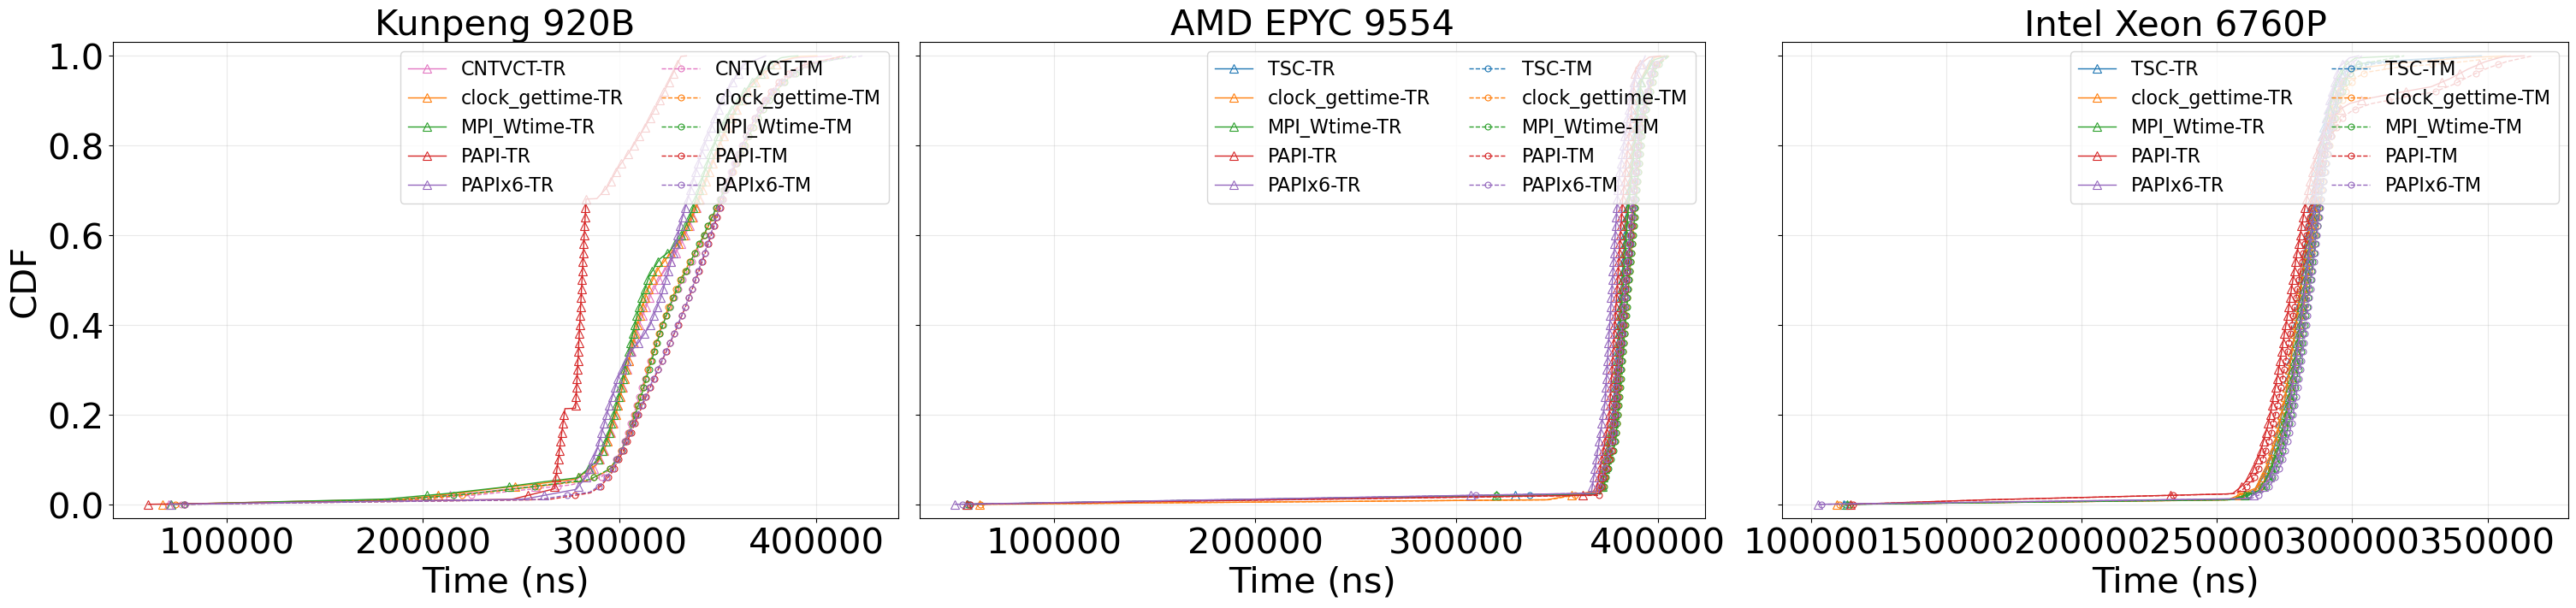

In [33]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 30
FILT_LABEL_FONTSIZE  = 30
FILT_TICK_FONTSIZE   = 30
FILT_LEGEND_FONTSIZE = 16

plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    if kernel != 'hpcg_spmv':
        continue

    print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 7), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            row['tm_median'] = np.median(row['tm_seq'])
            row['tr_median'] = np.median(row['tr_seq'])
            print(f"host={row['host']} timer={row['timer']}  tm_median={row['tm_median']:.2f} ns  tr_median={row['tr_median']:.2f} ns")

            tm_me = max(1, len(tm_x) // 50)
            tr_me = max(1, len(tr_x) // 50)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}", fontsize=FILT_TITLE_FONTSIZE)
        ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
        ax.grid(True, alpha=0.28)
        ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
        oh, ol = _ordered_tr_tm(ax)
        if oh:
            ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

    for ax in axes:
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)

    axes[0].set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
